# check the content produced by the summaries

In [9]:
import numpy as np
import os
from matplotlib import pyplot as plt
from src.evaluation import plotting
from src.evaluation.inference import Sampler
from IPython.display import Image, display


CUDA not avaliable, using CPU
2026 08 16  18 00 07 /data/dust/user/dayhallh/data/AllShowers/sliced_geant4/geant4_{}_of_200.h5
CUDA not avaliable, using CPU
2026 08 16  18 00 07 /data/dust/user/dayhallh/data/AllShowers/sliced_geant4/geant4_{}_of_200.h5


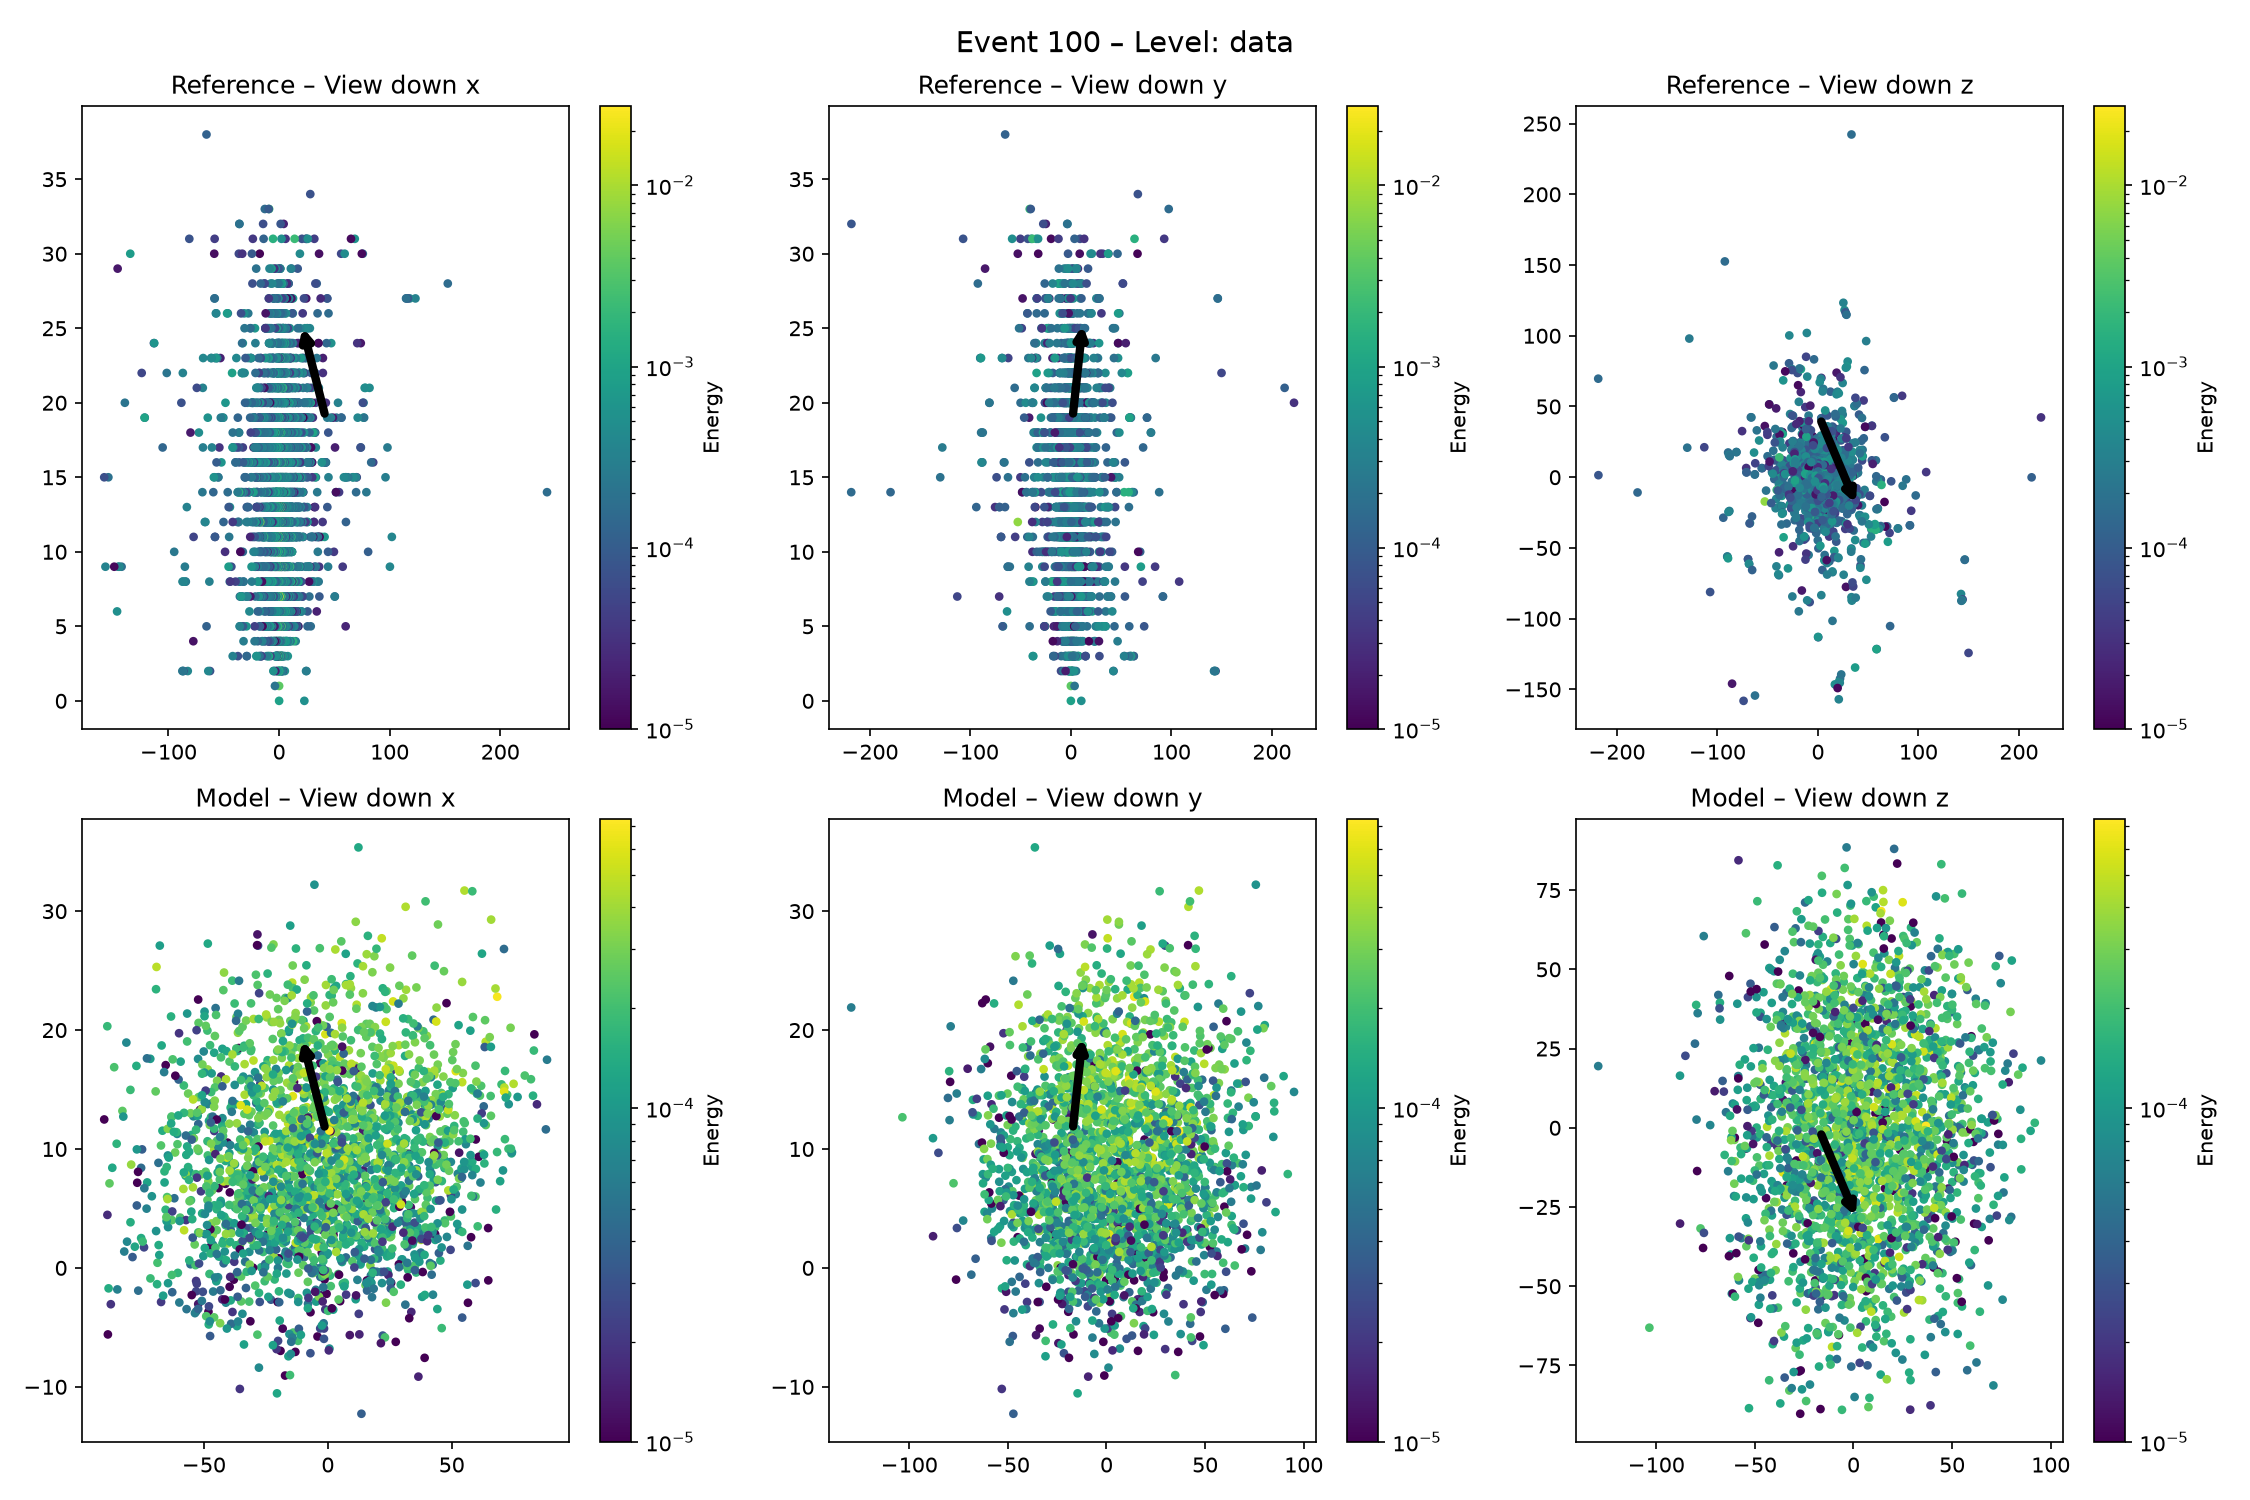

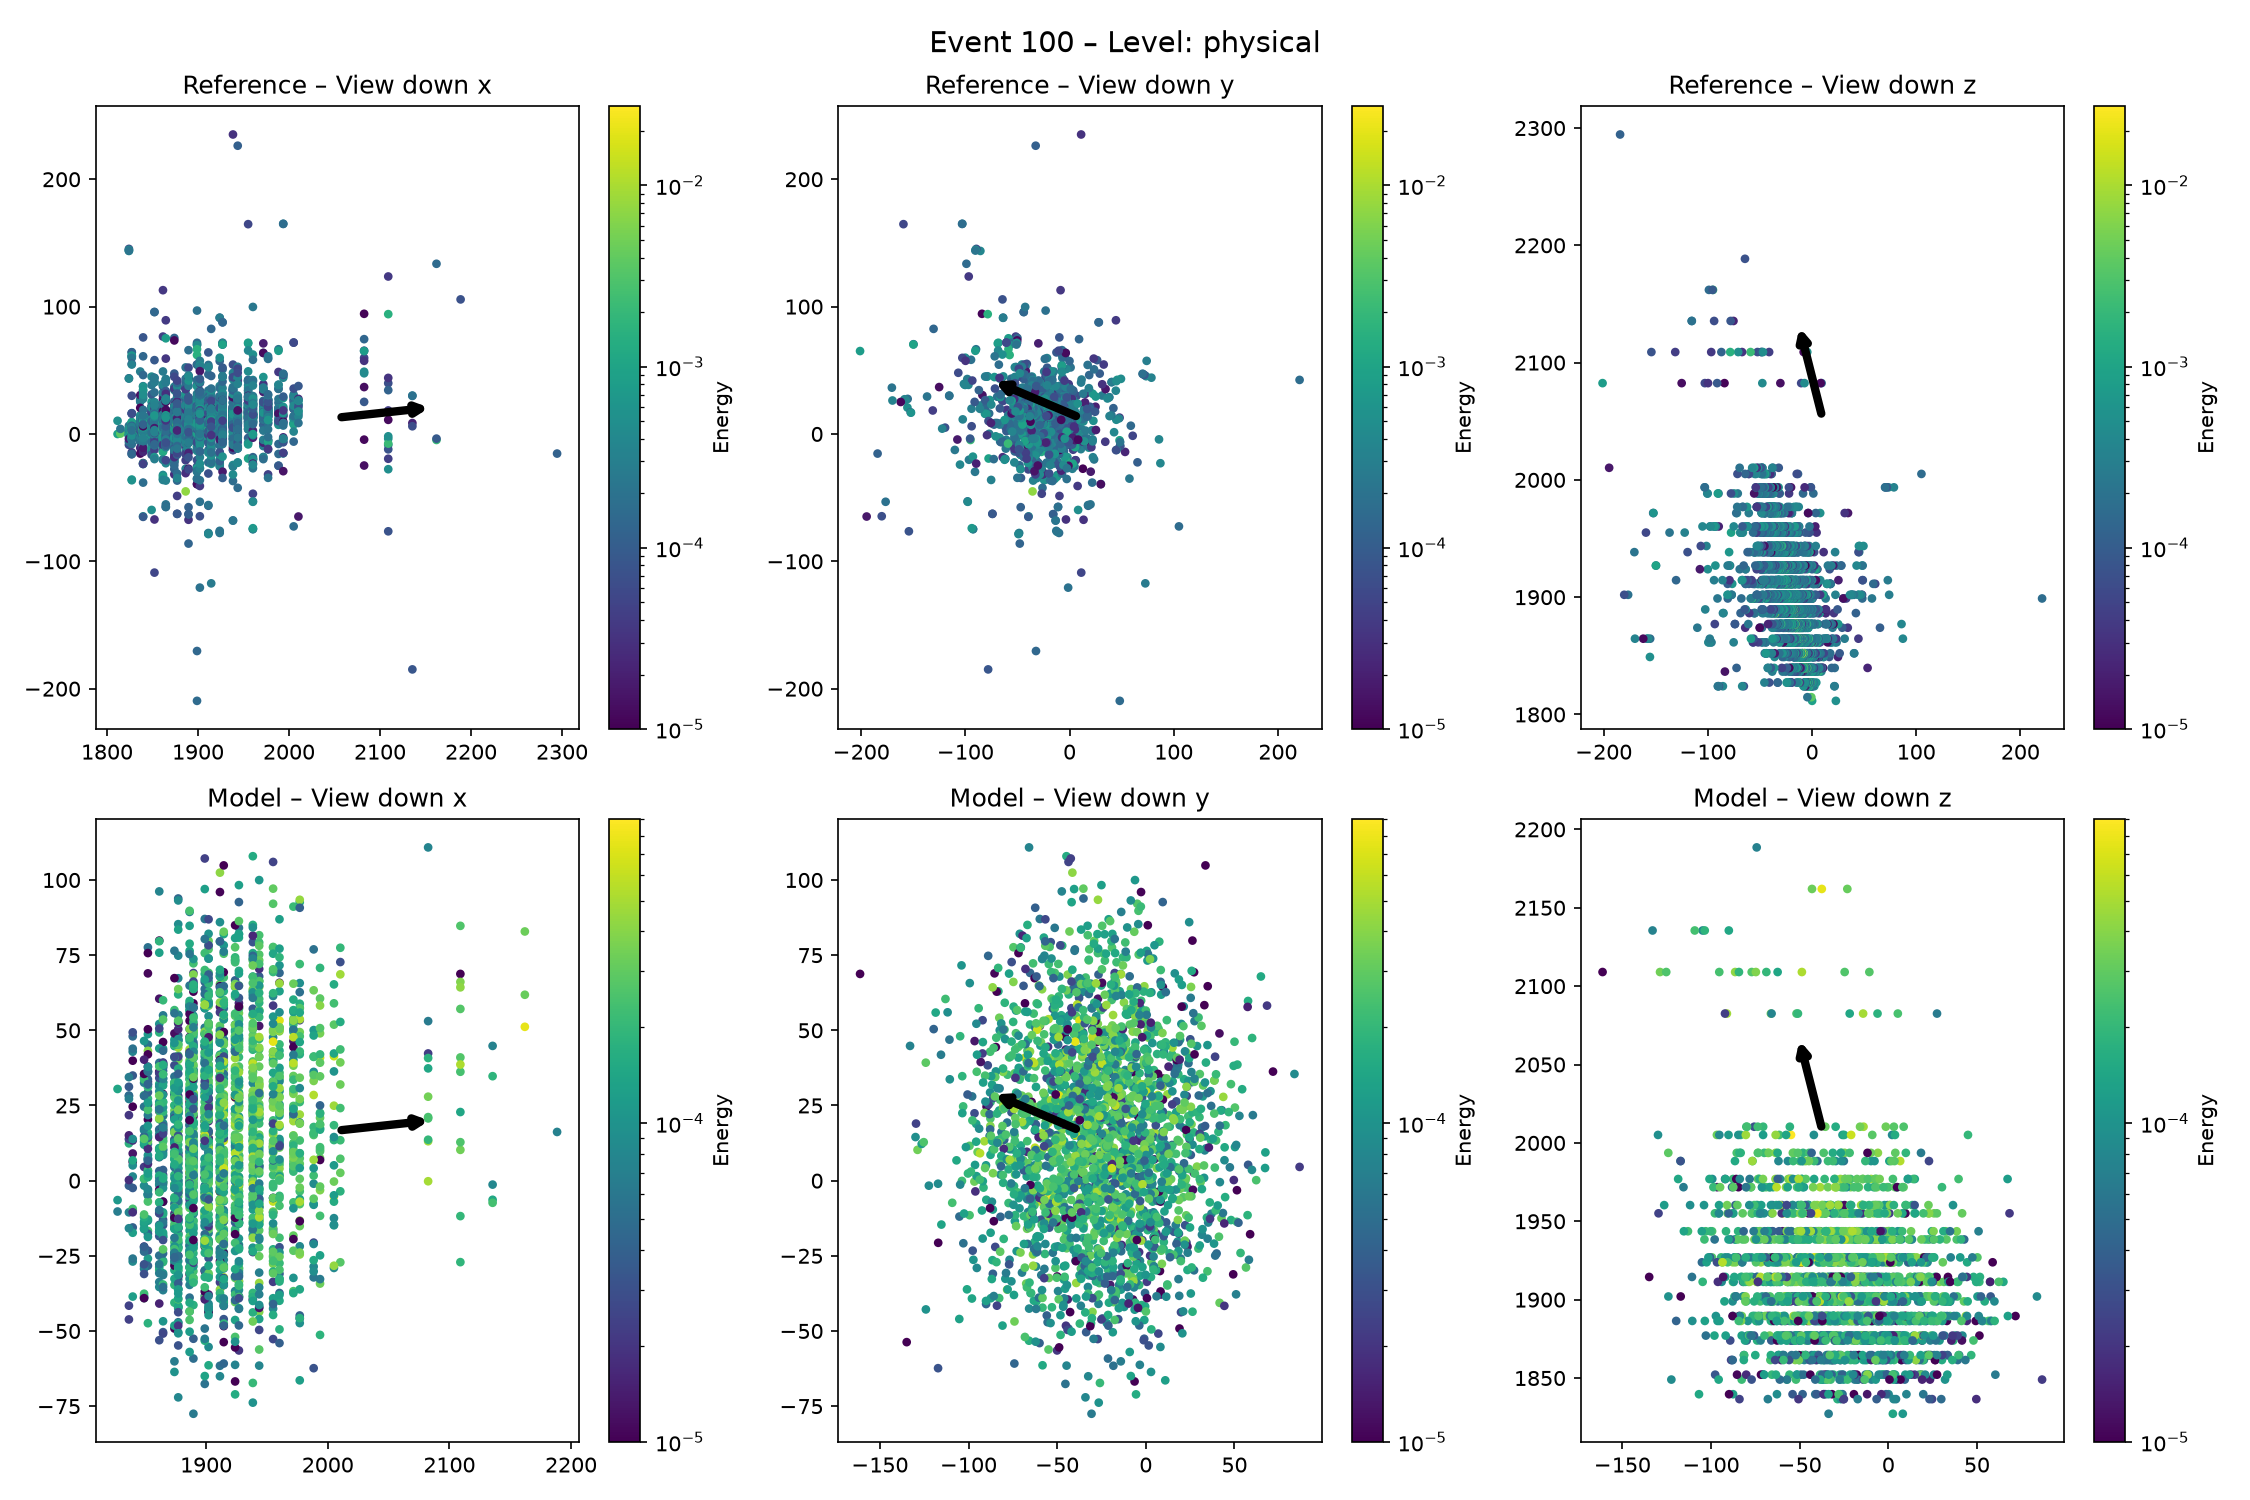

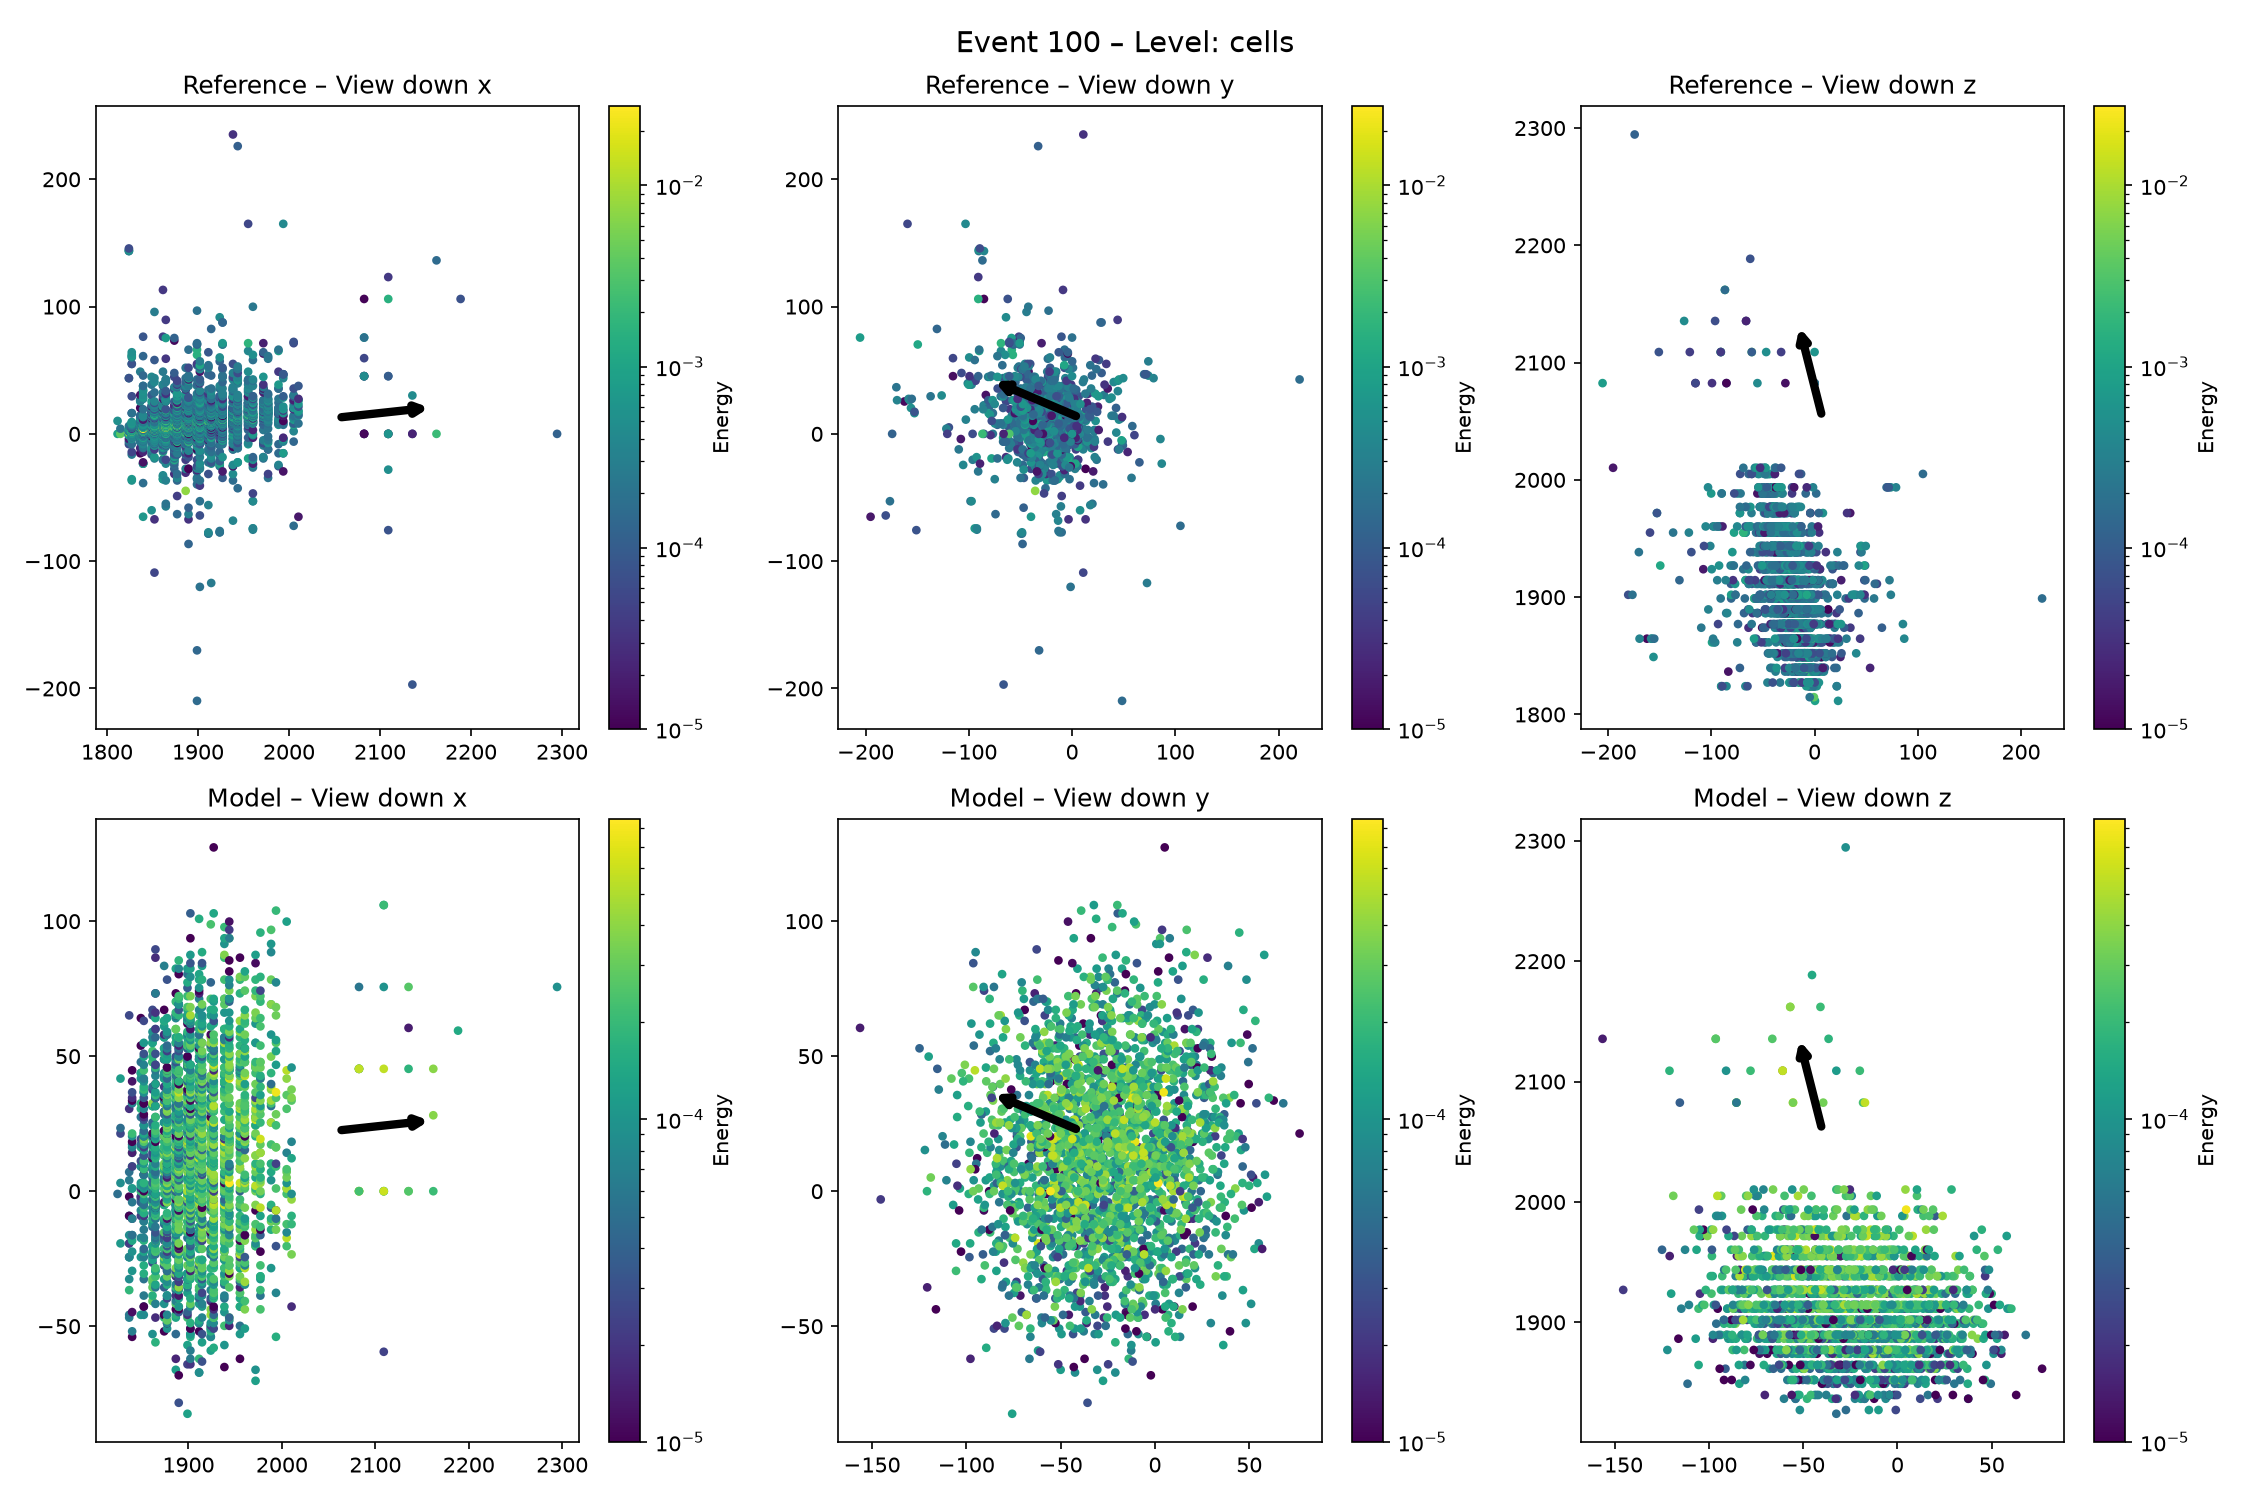

In [24]:
model_paths = ["/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/2026_08_16__18_00_07/checkpoints/2026-08-17_10-08-37_ema_model.pt",
               "/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/2026_08_16__18_00_07/checkpoints/2026-08-17_10-08-37_model.pt"]

configs = []
dates = []
infos = []
for path in model_paths:
    config = Sampler.get_config_from_model_path(path)
    configs.append(config)
    date = path.split('/')[-3].replace('_', ' ')
    dates.append(date)
    ds_path = config['data']['dataset_path']
    print(date, ds_path)
    info = f'{os.path.basename(ds_path).format("*")}'
    if path.endswith("_ema_model.pt"):
        info += " ema"
    infos.append(info)

if len(set(infos)) < len(infos):
    for i, date in dates:
        infos[i] += date

model_path = model_paths[0]
event_index = 100
for level in ["data", "physical", "cells"]:
    display(Image(filename=f'{model_path[:-3]}_{level}_{event_index}.png'))


In [25]:
ref_path = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/precalculated_reference/geant4_/pretest_Total1000_NoPick.npz"
sample_paths = [model_path.replace(".pt", "_summary.npz") for model_path in model_paths]

ref = np.load(ref_path)
# first dimension is events
print(len(ref.keys()), {key:ref[key].shape for key in list(ref.keys())})

13 {'cond': (1000, 5), 'pca': (1000, 3), 'pca_top4': (1000, 3), 'event_energy': (1000,), 'cell_energies': (1000, 49), 'cell_energies_edges': (50,), 'radial_energy': (1000, 49), 'radial_energy_edges': (50,), 'layer_energies': (1000, 78), 'event_occupancies': (1000,), 'radial_occupancies': (1000, 49), 'radial_occupancies_edges': (50,), 'layer_occupancies': (1000, 78)}


In [26]:

def pca_to_angles(pca):
    """Convert pca direction vectors into (theta, phi) angles.

    theta is measured from the z axis, phi is the angle in the x-y plane.
    """
    x = pca[:, 0]
    y = pca[:, 1]
    z = pca[:, 2]
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arccos(np.clip(z / r, -1.0, 1.0))
    phi = np.arctan2(y, x)
    return theta, phi


def augment_with_angles(data):
    """Return a dict copy of data with pca keys replaced by angle keys."""
    augmented = {}
    for key in data.keys():
        if "pca" in key and not key.endswith("_edges"):
            theta, phi = pca_to_angles(data[key])
            augmented[f"{key}_theta"] = theta
            augmented[f"{key}_phi"] = phi
        else:
            augmented[key] = data[key]
    return augmented


def bin_heights_and_edges(data, key):
    """Compute bin heights and edges for a given key."""
    values = data[key]
    edges_key = f"{key}_edges"
    if edges_key in data:
        edges = data[edges_key]
        heights = np.mean(values, axis=0)
    elif values.ndim == 1:
        ref_values = data[key]
        r_min, r_max = np.nanmin(ref_values), np.nanmax(ref_values)
        if abs(r_min - r_max) < 2:
            r_min -= 1
            r_max += 1
        r_min -= abs(r_min*0.1)
        r_max += abs(r_max*0.1)
        edges = np.linspace(r_min, r_max, 51)
        heights, _ = np.histogram(values, bins=edges)
    else:
        heights = np.mean(values, axis=0)
        edges = np.linspace(0, heights.shape[0], heights.shape[0] + 1)
    return heights, edges



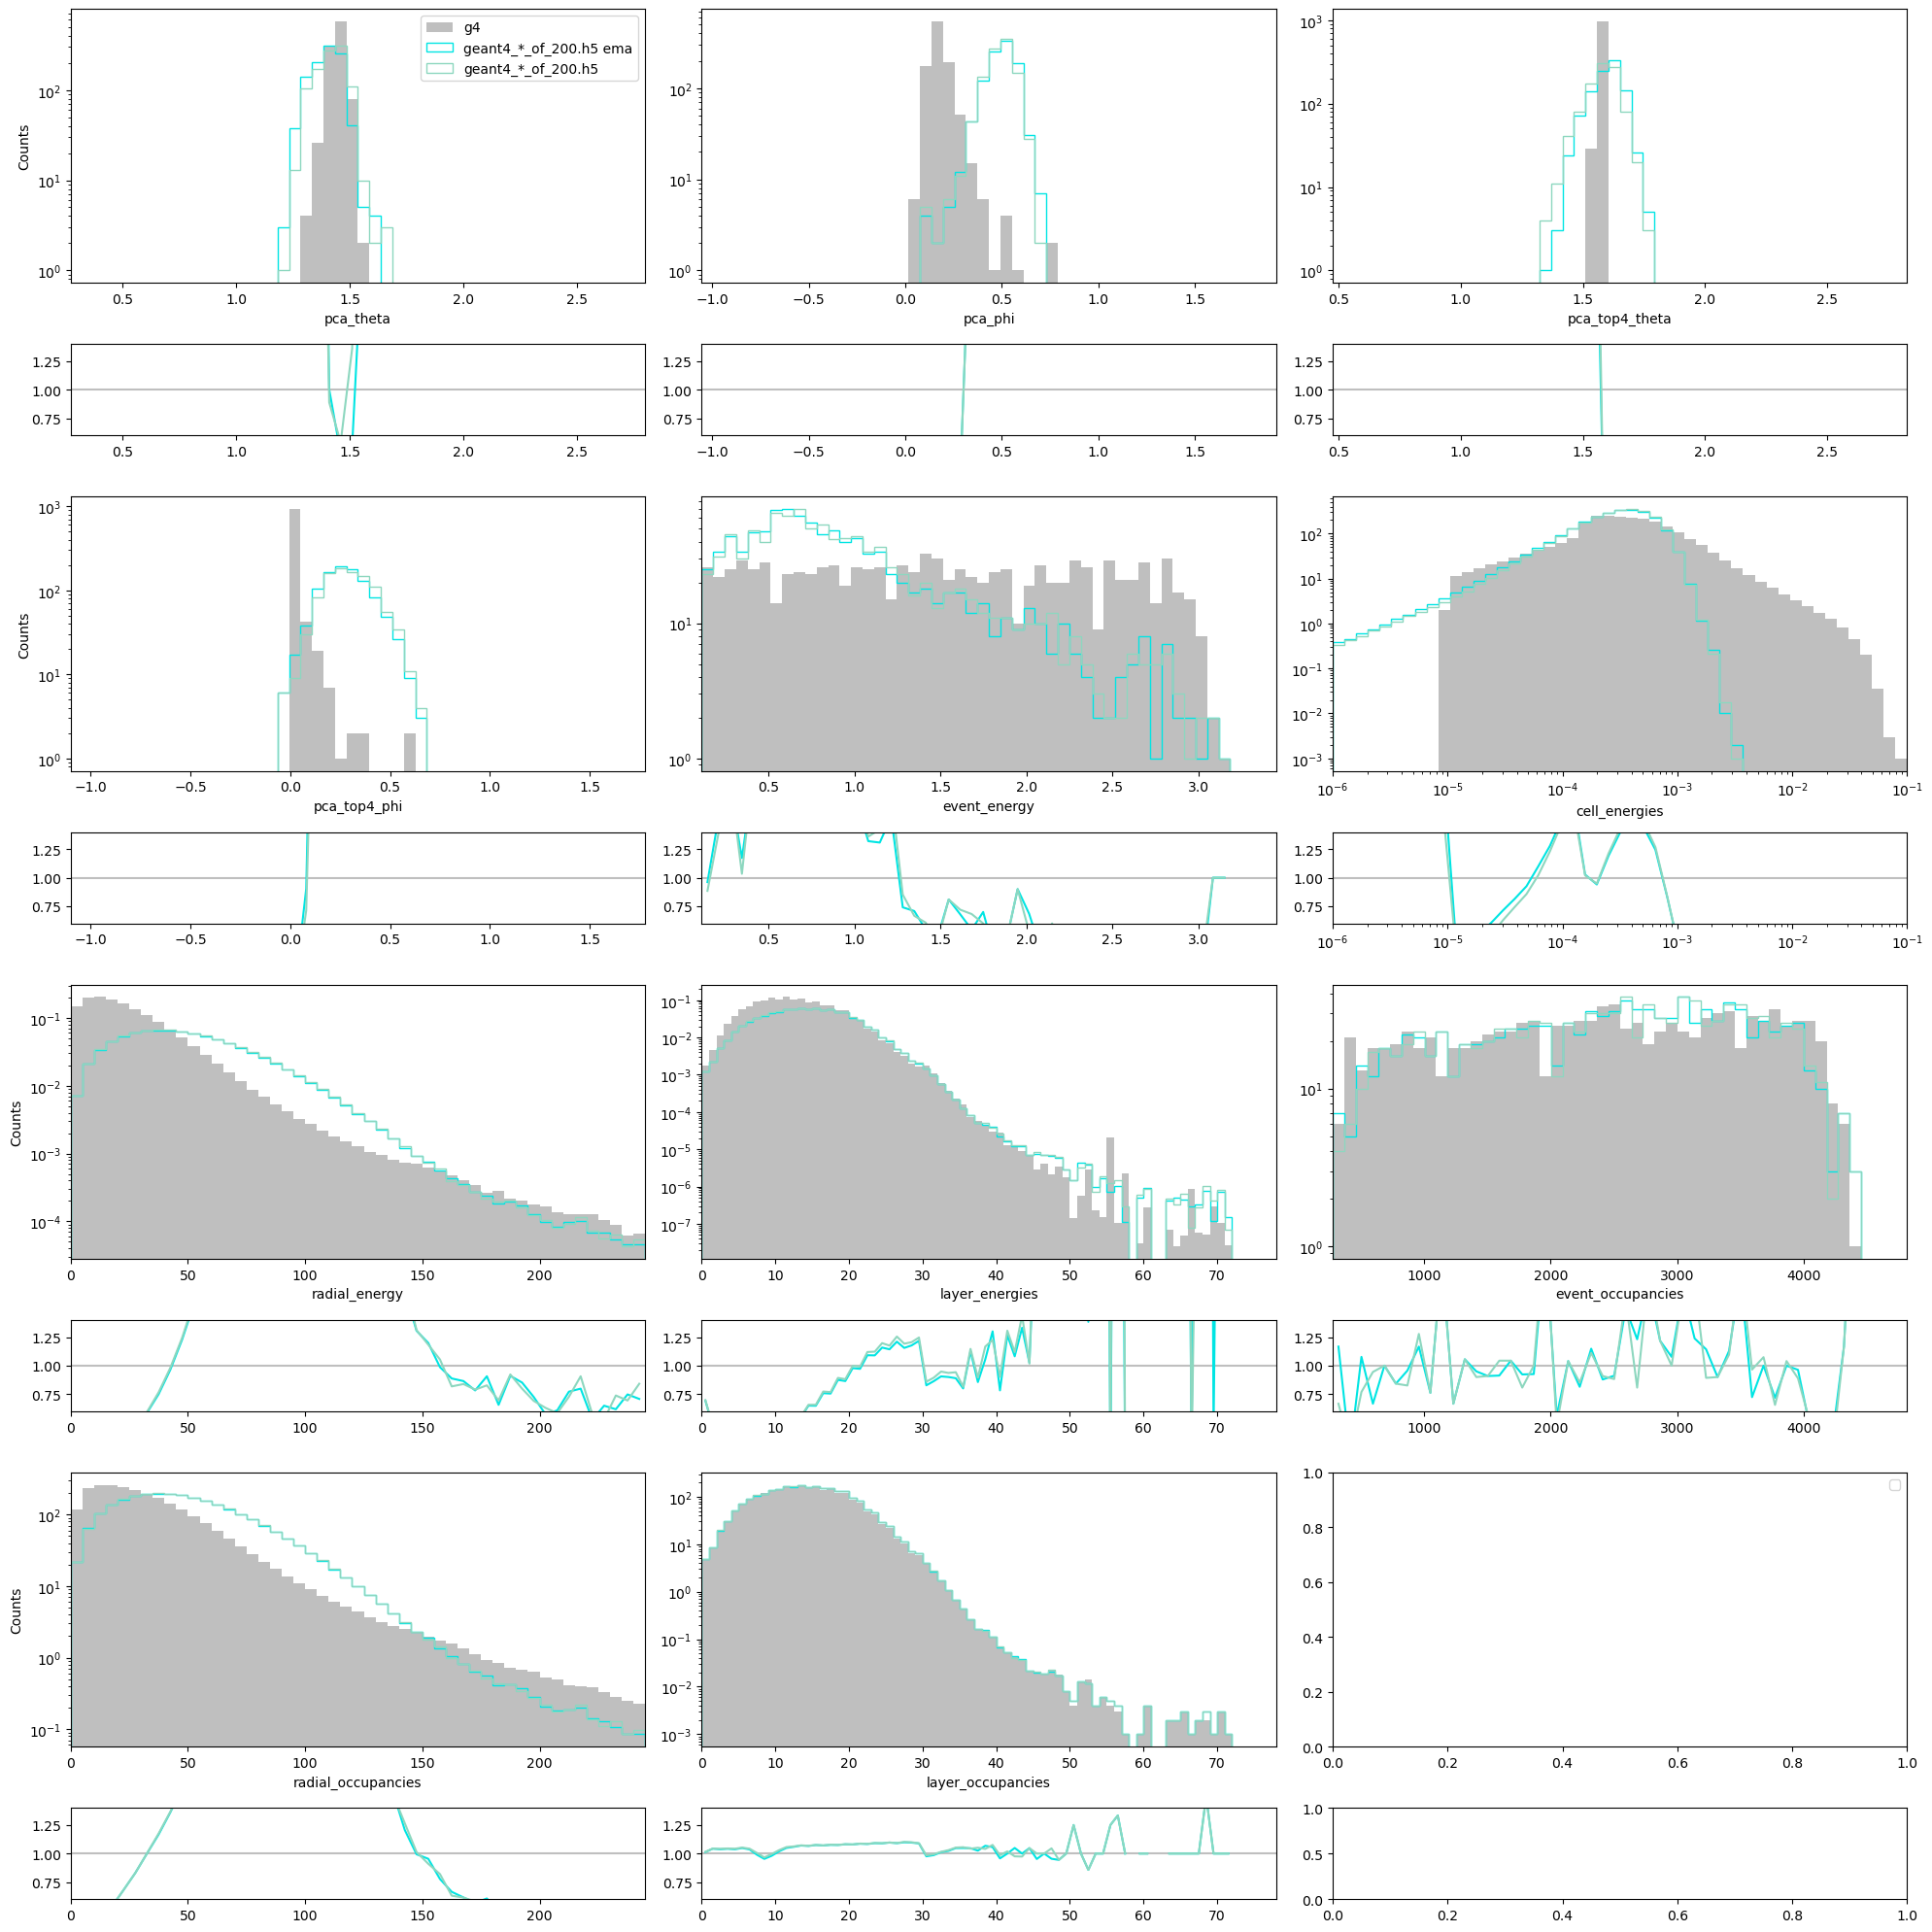

In [27]:
a_ref = augment_with_angles(ref)


# collect the keys to plot (skip cond and any *_edges keys)
plot_keys = [
    key
    for key in a_ref.keys()
    if key != "cond" and not key.endswith("_edges")
]


x_labels = plot_keys
ref_heights = []
binnings = []
for key in plot_keys:
    heights, edges = bin_heights_and_edges(a_ref, key)
    ref_heights.append(heights)
    binnings.append(edges)

logx = [x_label == "cell_energies" for x_label in x_labels]
logy = True

ratio_plots = plotting.RatioPlots(x_labels, ref_heights, binnings, logx=logx, logy=logy)


for i, sample_path in enumerate(sample_paths):
    sample = np.load(sample_path)

    a_sample = augment_with_angles(sample)

    sample_heights = [bin_heights_and_edges(a_sample, key)[0] for key in plot_keys]
    ratio_plots.add_comparison(sample_heights, label=infos[i], colour=plotting.nice_hex[0][i])
    
ratio_plots.axes[0,0].legend()
ratio_plots.finalise()